conditions: ['Baseline', 'H2-only', 'H1-only', 'Full']
helpers defined
[saved] 04_quantization_sweep.csv
[saved] 04_quantization_levels.csv
[saved] 04_quantization_pareto.png  &  04_quantization_pareto.pdf


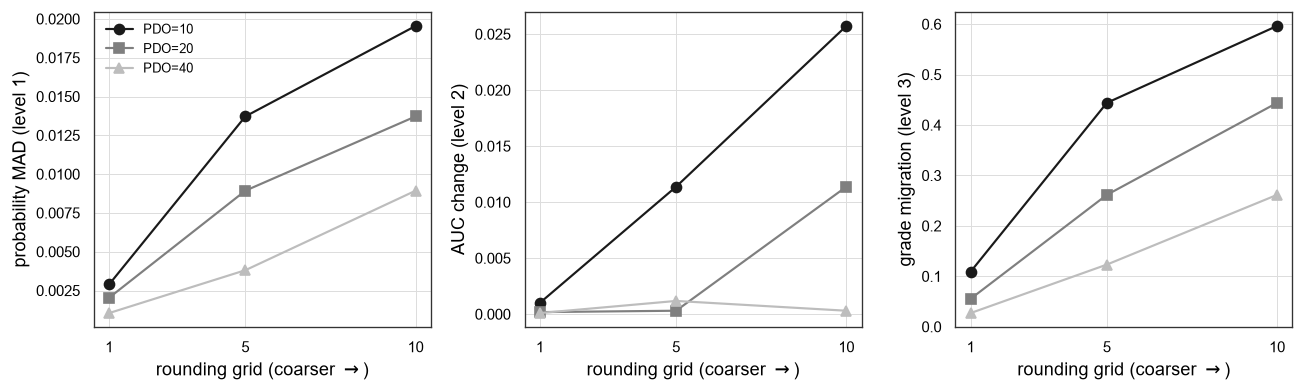

In [1]:
# Notebook 04 — Quantization Loss, Three Levels (Track B)

import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common as C
C.set_grayscale_style()

X = pd.read_pickle(C.PROC_DIR / "X_all.pkl")
y = np.load(C.PROC_DIR / "y_all.npy")
SP = pickle.load(open(C.PROC_DIR / "splits.pkl", "rb"))
store = pickle.load(open(C.PROC_DIR / "distilled_models.pkl", "rb"))
Xev, yev = X.iloc[SP["eval"]], y[SP["eval"]]

PDO_GRID  = [10, 20, 40]
CELL_GRID = [1, 5, 10]     # rounding grid unit
K_BANDS   = 7
print("conditions:", list(store))


# ----------------------------------------------------------------------------
# helpers: rank-reversal rate and grade-migration rate
# ----------------------------------------------------------------------------
def rank_reversal_rate(score_a, score_b, n_sample=1500, seed=C.RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(score_a)
    idx = rng.choice(n, min(n_sample, n), replace=False)
    a, b = np.asarray(score_a)[idx], np.asarray(score_b)[idx]
    da = np.sign(a[:, None] - a[None, :])
    db = np.sign(b[:, None] - b[None, :])
    iu = np.triu_indices(len(idx), k=1)
    da, db = da[iu], db[iu]
    comparable = da != 0
    if comparable.sum() == 0:
        return 0.0
    discordant = (da * db < 0) & comparable
    return float(discordant.sum() / comparable.sum())

def grade_migration_rate(score_a, score_b, k=K_BANDS):
    # higher score = safer; band by quantiles of each score independently
    ga = pd.qcut(pd.Series(score_a).rank(method="first"), k, labels=False)
    gb = pd.qcut(pd.Series(score_b).rank(method="first"), k, labels=False)
    return float(np.mean(ga.to_numpy() != gb.to_numpy()))
print("helpers defined")


# ----------------------------------------------------------------------------
# Sweep PDO x grid for every condition; continuous scorecard is FIXED per
# condition, only quantization changes (isolates Map-A round() loss).
# ----------------------------------------------------------------------------
records = []
for cond, obj in store.items():
    sc = obj["scorecard"]; binning = obj["binning"]
    Xev_b = C.apply_binning(Xev, binning)
    m_cont = sc.margin(Xev_b)
    p_cont = C.sigmoid(m_cont)
    auc_cont = C.auc(yev, p_cont)
    ece_cont = C.ece(yev, p_cont)
    brier_cont = C.brier_score(yev, p_cont)
    for pdo in PDO_GRID:
        for grid in CELL_GRID:
            sc.quantize(pdo=pdo, grid=grid, base_points=600)
            pts = sc.total_points(Xev_b)
            p_int = sc.quantized_proba(Xev_b)
            m_int = sc.quantized_margin(Xev_b)   # risk-oriented, same sign as m_cont
            dl = C.delong_test(yev, p_cont, p_int)
            records.append({
                "condition": cond, "PDO": pdo, "grid": grid,
                # level 1 (probability / calibration)
                "prob_MAD": float(np.mean(np.abs(p_cont - p_int))),
                "dECE": C.ece(yev, p_int) - ece_cont,
                "dBrier": C.brier_score(yev, p_int) - brier_cont,
                # level 2 (rank) — compare on the SAME (risk) orientation
                "dAUC": C.auc(yev, p_int) - auc_cont,
                "AUC_delong_p": dl["p_value"],
                "rank_reversal": rank_reversal_rate(m_cont, m_int),
                # level 3 (grade)
                "grade_migration": grade_migration_rate(m_cont, m_int),
                "n_distinct_scores": int(np.unique(pts).size),
            })
quant = pd.DataFrame(records)
C.save_table(quant.round(6), "04_quantization_sweep")
quant[quant.condition == "Full"].round(5)


# ----------------------------------------------------------------------------
# Level summary: mean loss across conditions per (PDO, grid)
# ----------------------------------------------------------------------------
lvl = (quant.groupby(["PDO", "grid"])
       .agg(prob_MAD=("prob_MAD", "mean"),
            dAUC=("dAUC", "mean"),
            rank_reversal=("rank_reversal", "mean"),
            grade_migration=("grade_migration", "mean"),
            n_distinct=("n_distinct_scores", "mean"))
       .reset_index())
C.save_table(lvl.round(5), "04_quantization_levels")
lvl.round(5)


# ----------------------------------------------------------------------------
# Figure: quantization Pareto — grid coarseness (X) vs per-level loss (Y)
#   grayscale, three panels (prob MAD / |dAUC| / grade migration)
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
styles = {10: ("o", "#1a1a1a"), 20: ("s", "#7f7f7f"), 40: ("^", "#bdbdbd")}
metrics = [("prob_MAD", "probability MAD (level 1)"),
           ("dAUC", "AUC change (level 2)"),
           ("grade_migration", "grade migration (level 3)")]
for ax, (mkey, title) in zip(axes, metrics):
    for pdo in PDO_GRID:
        sub = lvl[lvl.PDO == pdo].sort_values("grid")
        mk, col = styles[pdo]
        yv = sub[mkey].to_numpy()
        yv = np.abs(yv) if mkey == "dAUC" else yv
        ax.plot(sub["grid"], yv, marker=mk, color=col, linewidth=1.3,
                markersize=6, label=f"PDO={pdo}")
    ax.set_xlabel("rounding grid (coarser $\\rightarrow$)")
    ax.set_ylabel(title)
    ax.set_xticks(CELL_GRID)
axes[0].legend(title=None, fontsize=8)
fig.tight_layout()
C.save_fig(fig, "04_quantization_pareto")
plt.show()
